In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2025-02-15 01:32:53--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-02-15 01:32:53--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-02-15 01:32:54--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

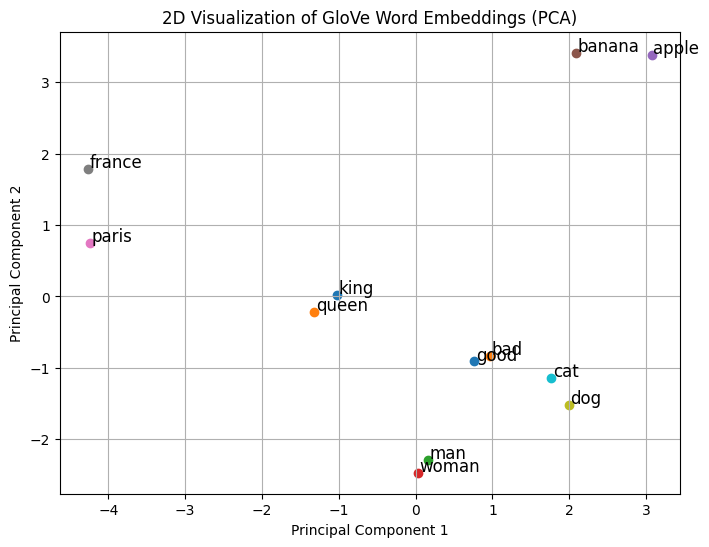

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load GloVe embeddings
glove_path = "/content/glove.6B.100d.txt"
embedding_index = {}

with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

# Select words to visualize
words_to_visualize = ["king", "queen", "man", "woman", "apple", "banana", "paris", "france", "dog", "cat","good","bad"]
vectors = np.array([embedding_index[word] for word in words_to_visualize])

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

# Plot the words
plt.figure(figsize=(8, 6))
for i, word in enumerate(words_to_visualize):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1], marker='o')
    plt.text(reduced_vectors[i, 0] + 0.02, reduced_vectors[i, 1] + 0.02, word, fontsize=12)

plt.title("2D Visualization of GloVe Word Embeddings (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()


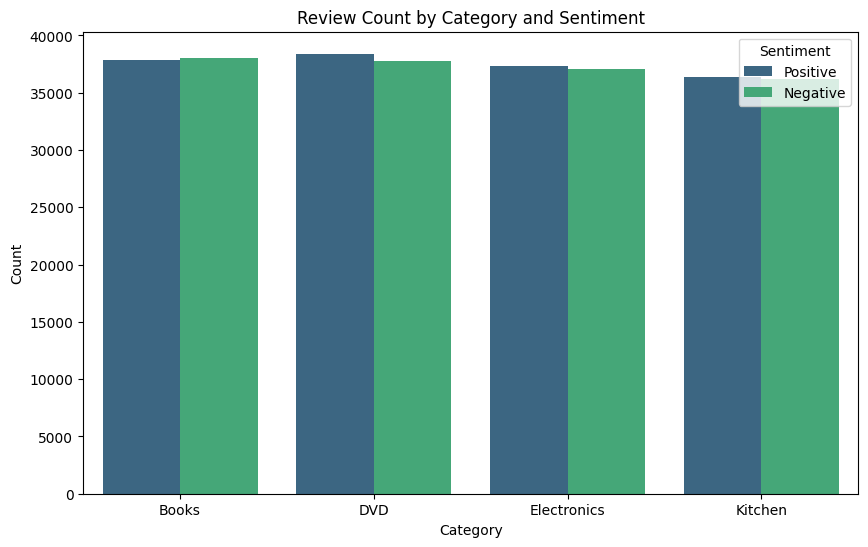

In [32]:
# Step 1: Import necessary libraries
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Step 2: Define the base path where the data is located
base_path = "/content/amazon_data/sorted_data_acl"

# Step 3: Create a function to load reviews into a DataFrame
def load_reviews(category, review_type):
    file_path = os.path.join(base_path, category, f"{review_type}.review")
    with open(file_path, "r", encoding="utf-8") as file:
        reviews = file.readlines()
    return pd.DataFrame(reviews, columns=["review_text"])

# Step 4: Load positive and negative reviews for each category
books_positive = load_reviews("books", "positive")
books_negative = load_reviews("books", "negative")

dvd_positive = load_reviews("dvd", "positive")
dvd_negative = load_reviews("dvd", "negative")

electronics_positive = load_reviews("electronics", "positive")
electronics_negative = load_reviews("electronics", "negative")

kitchen_positive = load_reviews("kitchen_&_housewares", "positive")
kitchen_negative = load_reviews("kitchen_&_housewares", "negative")

# Step 5: Create a summary DataFrame for visualization
data = {
    "Category": ["Books", "Books", "DVD", "DVD", "Electronics", "Electronics", "Kitchen", "Kitchen"],
    "Sentiment": ["Positive", "Negative", "Positive", "Negative", "Positive", "Negative", "Positive", "Negative"],
    "Count": [
        len(books_positive), len(books_negative),
        len(dvd_positive), len(dvd_negative),
        len(electronics_positive), len(electronics_negative),
        len(kitchen_positive), len(kitchen_negative)
    ]
}

summary_df = pd.DataFrame(data)

# Step 6: Plot review counts by category and sentiment
plt.figure(figsize=(10, 6))
sns.barplot(x="Category", y="Count", hue="Sentiment", data=summary_df, palette="viridis")
plt.title("Review Count by Category and Sentiment")
plt.show()



In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.regularizers import l2
import tensorflow_datasets as tfds
import numpy as np

# Load Yelp Polarity dataset
dataset, info = tfds.load('yelp_polarity_reviews', with_info=True, as_supervised=True)
train_data, test_data = dataset['train'], dataset['test']

# Prepare the data
vocab_size = 50000  # Limit vocabulary to top 50,000 words
max_length = 200    # Maximum review length (truncation/padding)

# Tokenizer to convert text to sequences
tokenizer = keras.preprocessing.text.Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts([text.numpy().decode('utf-8') for text, _ in train_data])

# Convert text data to sequences and pad them
def preprocess_dataset(dataset):
    texts, labels = [], []
    for text, label in dataset:
        texts.append(text.numpy().decode('utf-8'))
        labels.append(label.numpy())
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    return padded_sequences, np.array(labels)

# Preprocess training and testing data
tr_x, tr_y = preprocess_dataset(train_data)
te_x, te_y = preprocess_dataset(test_data)

# Load GloVe 6B embeddings
glove_path = "/content/glove.6B.100d.txt"  # Update with the correct path
embedding_dim = 100  # Choose dimension (50d, 100d, 200d, or 300d)

# Create a dictionary mapping words to vectors
embeddings_index = {}
with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

# Create an embedding matrix for the tokenizer’s vocabulary
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# Build the model with GloVe
model = keras.Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,
              input_length=max_length, weights=[embedding_matrix],
              trainable=True),  # Use pretrained embeddings, freeze weights
    Bidirectional(LSTM(32, return_sequences=True, kernel_regularizer=l2(0.001))),  # Bidirectional LSTM
    Dropout(0.4),  # Dropout to prevent overfitting
    GlobalAveragePooling1D(),  # Average pooling over time steps
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),  # Fully connected layer with L2 reg
    Dropout(0.4),  # Dropout before output layer
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Add early stopping
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train the model
model.fit(tr_x, tr_y, epochs=20, batch_size=64, validation_data=(te_x, te_y), callbacks=[early_stopping])

# Evaluate the model
test_loss, test_acc = model.evaluate(te_x, te_y)
print(f"Test Accuracy: {test_acc:.4f}")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/560000 [00:00<?, ? examples/s]

...

Generating test examples...:   0%|          | 0/38000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/yelp_polarity_reviews/incomplete.Z24RUR_0.2.0/yelp_polarity_reviews-test.t…

Dataset yelp_polarity_reviews downloaded and prepared to /root/tensorflow_datasets/yelp_polarity_reviews/0.2.0. Subsequent calls will reuse this data.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 182s 20ms/step - accuracy: 0.8862 - loss: 0.3284 - val_accuracy: 0.9443 - val_loss: 0.1653
Epoch 2/20
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 179s 20ms/step - accuracy: 0.9488 - loss: 0.1548 - val_accuracy: 0.9460 - val_loss: 0.1529
Epoch 3/20
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 199s 20ms/step - accuracy: 0.9579 - loss: 0.1318 - val_accuracy: 0.9465 - val_loss: 0.1531
Epoch 4/20
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 176s 20ms/step - accuracy: 0.9651 - loss: 0.1136 - val_accuracy: 0.9438 - val_loss: 0.1604
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9471 - loss: 0.1552
Test Accuracy: 0.9460


In [36]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Function to predict sentiment of input text
def predict_sentiment(model, text, tokenizer, max_length=200):
    # Convert text to sequence using the tokenizer
    sequence = tokenizer.texts_to_sequences([text])

    # Pad the sequence to the fixed length
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')

    # Get prediction probability
    prediction = model.predict(padded_sequence)[0][0]

    # Classify sentiment
    sentiment = "Positive" if prediction > 0.5 else "Negative"

    # Confidence score
    confidence = prediction if sentiment == "Positive" else 1 - prediction

    return sentiment, confidence


In [42]:
# Function to decode a sequence back to text
def sequence_to_text(sequence, tokenizer):
    return tokenizer.sequences_to_texts([sequence])[0]


 #List of positive and negative reviews to test
test_reviews = [
    # Positive reviews
    "The food was absolutely delicious, and the service was exceptional!",
    "I had a wonderful experience at this restaurant. The ambiance was perfect, and the staff was very friendly.",
    "Highly recommend this place! The dishes were flavorful, and the presentation was stunning.",

    # Negative reviews
    "The worst experience ever. The food was cold, and the waiter was rude.",
    "I was extremely disappointed with the service. The staff ignored us, and the food was overpriced.",
    "Terrible quality. The place was dirty, and the food tasted awful."
]

# Function to predict sentiment for a list of reviews
def test_reviews_sentiment_firstcell(model, reviews, tokenizer, max_length=200):
    for review in reviews:
        # Predict sentiment
        sentiment, confidence = predict_sentiment(model, review, tokenizer, max_length)

        # Print results
        print(f"Review: {review}")
        print(f"Predicted Sentiment: {sentiment} (Confidence: {confidence:.4f})")
        print("-" * 50)

# Test the reviews
test_reviews_sentiment_firstcell(model, test_reviews, tokenizer)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Review: The food was absolutely delicious, and the service was exceptional!
Predicted Sentiment: Positive (Confidence: 0.9989)
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Review: I had a wonderful experience at this restaurant. The ambiance was perfect, and the staff was very friendly.
Predicted Sentiment: Positive (Confidence: 0.9983)
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Review: Highly recommend this place! The dishes were flavorful, and the presentation was stunning.
Predicted Sentiment: Positive (Confidence: 0.9989)
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Review: The worst experience ever. The food was cold, and the waiter was rude.
Predicted Sentiment: Negative (Confidence: 0.9990)
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Review: I was extremely disappoi

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


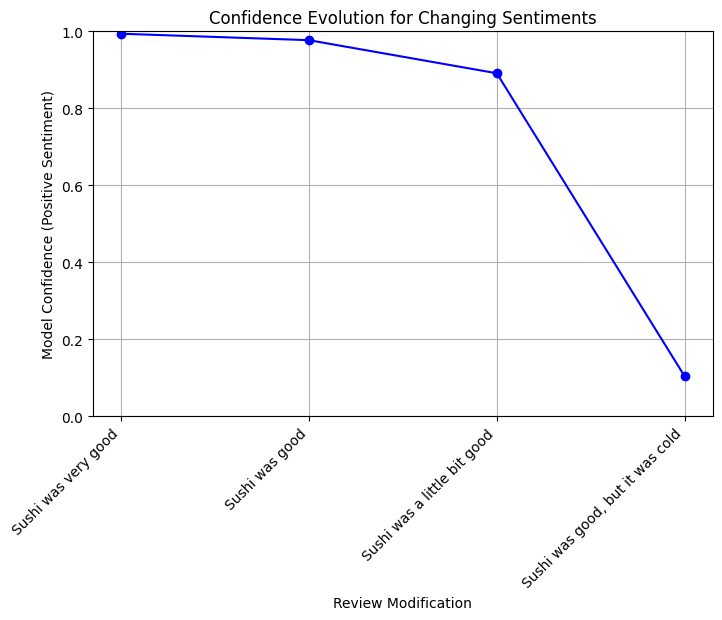

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Review: Sushi was good, but it was cold
Predicted Sentiment: Negative (Confidence: 0.8957)
--------------------------------------------------


In [40]:
def test_reviews_sentiment(model, reviews, tokenizer):
    sequences = tokenizer.texts_to_sequences(reviews)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    predictions = model.predict(padded_sequences)
    return predictions.flatten().tolist()  # Convert to list for easy indexing
import matplotlib.pyplot as plt

# Define test reviews with sentiment variations
test_reviews = [
    "Sushi was very good",
    "Sushi was good",
    "Sushi was a little bit good",
    "Sushi was good, but it was cold"
]

# Ensure function returns predictions
confidence_scores = [test_reviews_sentiment(model, [review], tokenizer)[0] for review in test_reviews]

# Plot confidence evolution
plt.figure(figsize=(8, 5))
plt.plot(range(len(test_reviews)), confidence_scores, marker='o', linestyle='-', color='b')
plt.xticks(range(len(test_reviews)), test_reviews, rotation=45, ha='right')
plt.xlabel("Review Modification")
plt.ylabel("Model Confidence (Positive Sentiment)")
plt.title("Confidence Evolution for Changing Sentiments")
plt.ylim([0, 1])  # Sigmoid output is between 0 and 1
plt.grid()
plt.show()

text2=["Sushi was good, but it was cold"]
test_reviews_sentiment_firstcell(model, text2, tokenizer)

In [43]:
model.save("sentiment_analysis_model.h5")

In [70]:
import random
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
load_model = keras.models.load_model("sentiment_analysis_model.h5")
def perturb_word(word, attack_type="random"):
    """Applies character-level perturbations to a word."""
    if len(word) < 3:
        return word  # Avoid modifying very short words

    if attack_type == "random":
        attack_type = random.choice(["swap", "replace", "insert"])

    word = list(word)

    if attack_type == "swap" and len(word) > 3:
        i = random.randint(1, len(word) - 2)  # Avoid first and last character
        word[i], word[i + 1] = word[i + 1], word[i]

    elif attack_type == "replace":
        char_map = {'a': '@', 'e': '3', 'i': '1', 'o': '0', 's': '$', 't': '7'}
        i = random.randint(0, len(word) - 1)
        if word[i] in char_map:
            word[i] = char_map[word[i]]

    elif attack_type == "insert":
        i = random.randint(1, len(word) - 1)
        word.insert(i, random.choice("abcdefghijklmnopqrstuvwxyz"))

    return "".join(word)

def adversarial_attack(model, text, tokenizer, max_length=200, max_attempts=10, attack_prob=0.7, attack_type="random"):
    """Applies a character-level adversarial attack to flip the sentiment."""
    words = text.split()
    original_sentiment, confidence = predict_sentiment(model, text, tokenizer, max_length)

    print(f"Original Text: {text}")
    print(f"Original Sentiment: {original_sentiment} (Confidence: {confidence:.2f})")

    for _ in range(max_attempts):
        modified_text = words.copy()
        modifications = []

        for i in range(len(modified_text)):
            if random.random() < attack_prob:  # Apply attack based on probability
                original_word = modified_text[i]
                modified_text[i] = perturb_word(modified_text[i], attack_type)
                modifications.append((original_word, modified_text[i]))

        modified_text = " ".join(modified_text)

        new_sentiment, new_confidence = predict_sentiment(model, modified_text, tokenizer, max_length)

        if new_sentiment != original_sentiment:
            print(f"Adversarial Text: {modified_text}")
            print(f"Modifications: {modifications}")
            print(f"New Sentiment: {new_sentiment} (Confidence: {new_confidence:.2f})\n")
            return modified_text, new_sentiment, new_confidence

    print("Attack failed to flip sentiment.")
    return text, original_sentiment, confidence  # Return original if attack fails

# Test cases for adversarial attacks
def test_adversarial_attack(model, tokenizer, attack_type="random"):
    test_cases = [
       # "The food was disgusting, and the service was absolutely terrible. Never coming back!",
        #"Absolutely amazing food! The flavors were incredible, and the staff was so friendly.",
        #"The restaurant was okay. The food was decent, but nothing special.",
        #"The pizza was cold, and the waiter was rude.",
        "The coffee was perfect, and the ambiance was cozy.",
        "I went to this place with high expectations, but I was really disappointed. The pasta was overcooked, the sauce was bland, and the service was incredibly slow. Honestly, I don't think I’ll be coming back anytime soon."
    ]

    for text in test_cases:
        adv_text, new_sentiment, confidence = adversarial_attack(model, text, tokenizer, attack_type=attack_type)

# Call the function to test adversarial attacks
#if __name__ == "__main__":
 #   test_adversarial_attack(model, tokenizer, )


**ON ATTACK PROBABILITY=0.3 , MAX ATTEMPTS=10**

In [59]:

test_adversarial_attack(model, tokenizer,attack_type="replace")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Original Text: The coffee was perfect, and the ambiance was cozy.
Original Sentiment: Positive (Confidence: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Adversarial Text: The coffee was perfec7, @nd the ambiance was cozy.
Modifications: [('perfect,', 'perfec7,'), ('and', '@nd')]
New Sentiment: Negative (Confidence: 0.50)



In [61]:

test_adversarial_attack(model, tokenizer,attack_type="swap")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Original Text: The coffee was perfect, and the ambiance was cozy.
Original Sentiment: Positive (Confidence: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Adversarial Text: The coffee was perefct, and the amibance was coz.y
Modifications: [('coffee', 'coffee'), ('was', 'was'), ('perfect,', 'perefct,'), ('ambiance', 'amibance'), ('cozy.', 'coz.y')]
New Sentiment: Negative (Confidence: 0.73)



In [63]:

test_adversarial_attack(model, tokenizer,attack_type="insert")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Original Text: The coffee was perfect, and the ambiance was cozy.
Original Sentiment: Positive (Confidence: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Adversarial Text: The coffee was perifect, and the ambiance was cokzy.
Modifications: [('perfect,', 'perifect,'), ('cozy.', 'cokzy.')]
New Sentiment: Negative (Confidence: 0.53)



In [71]:

test_adversarial_attack(model, tokenizer,attack_type="insert")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Original Text: The coffee was perfect, and the ambiance was cozy.
Original Sentiment: Positive (Confidence: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Adversarial Text: The coffeke was perfects, acnd the ambiawnce wass colzy.
Modifications: [('coffee', 'coffeke'), ('perfect,', 'perfects,'), ('and', 'acnd'), ('ambiance', 'ambiawnce'), ('was', 'wass'), ('cozy.', 'colzy.')]
New Sentiment: Negative (Confidence: 0.59)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Original Text: I went to this place with high expectations, but I was really disappointed. The pasta was overcooked, the sauce was bland, and the service was incredibly slow. Honestly, I don't think I’ll be coming back anytime soon.
Original Sentiment: Negative (Confidence: 1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/s